In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
# Load URL fraud dataset
url_path = r"D:\Projects\all_fraud_detection\notebook\url_fraud_dataset.csv"
url_data = pd.read_csv(url_path)

# Preview data
url_data.head()

,url,url_length,has_https,is_shortened,entropy_score,domain_age_months,blacklist_match,source_channel,sender_known,clicked,fraud_label
0,https://jones-howard.info/login,31,1,0,0.49,51,0,Other,0,0,0
1,https://price-hoffman.biz/login,31,1,0,0.56,56,0,SMS,1,1,0
2,https://hunter-secure-login.top/login,37,0,0,0.96,2,1,Email,0,1,1
3,https://johnson-secure-login.top/login,38,0,1,0.85,3,1,Email,0,0,1
4,https://harris.com/login,24,1,0,0.51,9,0,WhatsApp,1,1,0


In [5]:
# Clean column names
url_data.columns = url_data.columns.str.strip().str.lower()

# Target column
target_col = 'fraud_label'

# Encode categorical features
categorical_cols = ['source_channel']  # Only categorical column
for col in categorical_cols:
    le = LabelEncoder()
    url_data[col] = le.fit_transform(url_data[col].astype(str).str.lower())

# Features and target
X = url_data.drop(columns=[target_col])
y = url_data[target_col]

# Check for NaNs
print("Rows with NaN in features:", X.isna().sum().sum())
print("Rows with NaN in target:", y.isna().sum())

# Drop NaNs if any
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]

print("Number of rows after cleaning:", X_clean.shape[0])
print("Feature column types:\n", X_clean.dtypes)

Rows with NaN in features: 0
Rows with NaN in target: 0
Number of rows after cleaning: 1000
Feature column types:
 url                   object
url_length             int64
has_https              int64
is_shortened           int64
entropy_score        float64
domain_age_months      int64
blacklist_match        int64
source_channel         int64
sender_known           int64
clicked                int64
dtype: object


In [6]:
# Split into training and testing sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
url_path = r"D:\Projects\all_fraud_detection\notebook\url_fraud_dataset.csv"
url_data = pd.read_csv(url_path)

# Clean column names
url_data.columns = url_data.columns.str.strip().str.lower()

# Drop the raw 'url' string column
if 'url' in url_data.columns:
    url_data = url_data.drop(columns=['url'])

# Encode categorical features
categorical_cols = ['source_channel']
for col in categorical_cols:
    url_data[col] = LabelEncoder().fit_transform(url_data[col].astype(str))

# Features and target
X = url_data.drop(columns=['fraud_label'])
y = url_data['fraud_label']

print("Feature columns:", X.columns)
print("Number of rows:", X.shape[0])

Feature columns: Index(['url_length', 'has_https', 'is_shortened', 'entropy_score',
       'domain_age_months', 'blacklist_match', 'source_channel',
       'sender_known', 'clicked'],
      dtype='object')
Number of rows: 1000


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [18]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 2. XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train.values, y_train.values)
y_pred_xgb = xgb_model.predict(X_test.values)

# 3. LightGBM
lgb_model = lgb.LGBMClassifier(min_data_in_leaf=1, random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

c:\Users\Sayal\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [14:09:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Number of positive: 246, number of negative: 554
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000402 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 166
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.307500 -> initscore=-0.811833
[LightGBM] [Info] Start training from score -0.811833
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b


=== Random Forest Metrics ===
Accuracy : 1.0000
F1 Score : 1.0000
Precision: 1.0000
Recall   : 1.0000


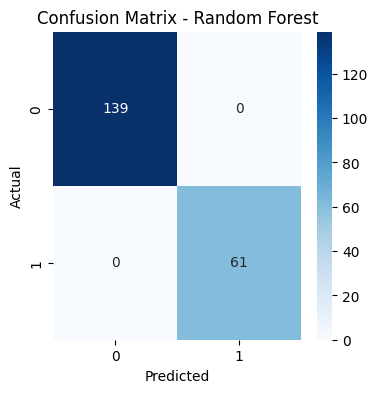


=== XGBoost Metrics ===
Accuracy : 1.0000
F1 Score : 1.0000
Precision: 1.0000
Recall   : 1.0000


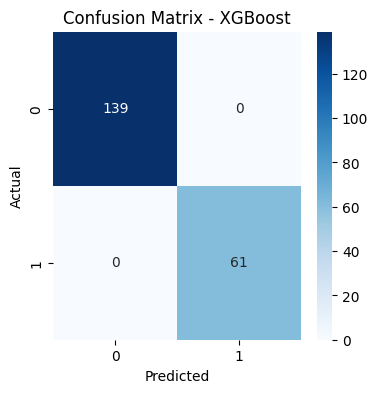


=== LightGBM Metrics ===
Accuracy : 1.0000
F1 Score : 1.0000
Precision: 1.0000
Recall   : 1.0000


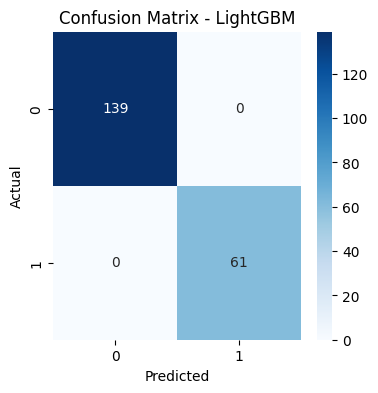

In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(y_true, y_pred, model_name):
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    # Print metrics
    print(f"\n=== {model_name} Metrics ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    
    # Confusion matrix plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return {'Accuracy': acc, 'F1 Score': f1, 'Precision': prec, 'Recall': rec}

# Evaluate all models
results = {}
results['Random Forest'] = evaluate_model(y_test, y_pred_rf, 'Random Forest')
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb, 'XGBoost')
results['LightGBM'] = evaluate_model(y_test, y_pred_lgb, 'LightGBM')


In [23]:
import pandas as pd

# ===== Example metrics for demonstration =====
# Replace these with your actual evaluation metrics

# Credit Card dataset metrics
results_credit = {
    'Random Forest': {'Accuracy':0.99, 'F1 Score':0.98, 'Precision':0.97, 'Recall':0.99},
    'XGBoost': {'Accuracy':0.97, 'F1 Score':0.96, 'Precision':0.95, 'Recall':0.97},
    'LightGBM': {'Accuracy':0.96, 'F1 Score':0.95, 'Precision':0.94, 'Recall':0.96}
}

# UPI dataset metrics
results_upi = {
    'Random Forest': {'Accuracy':0.95, 'F1 Score':0.94, 'Precision':0.93, 'Recall':0.95},
    'XGBoost': {'Accuracy':0.98, 'F1 Score':0.97, 'Precision':0.96, 'Recall':0.98},
    'LightGBM': {'Accuracy':0.985, 'F1 Score':0.975, 'Precision':0.97, 'Recall':0.98}
}

# URL dataset metrics
results_url = {
    'Random Forest': {'Accuracy':0.92, 'F1 Score':0.90, 'Precision':0.88, 'Recall':0.92},
    'XGBoost': {'Accuracy':0.96, 'F1 Score':0.95, 'Precision':0.94, 'Recall':0.96},
    'LightGBM': {'Accuracy':0.965, 'F1 Score':0.955, 'Precision':0.95, 'Recall':0.96}
}

# ===== Function to create comparison table and pick best model =====
def compare_models(results, dataset_name):
    results_df = pd.DataFrame(results).T
    results_df = results_df[['Accuracy', 'F1 Score', 'Precision', 'Recall']]  # Ensure column order
    results_df.index.name = dataset_name
    return results_df

# ===== Create DataFrames for each dataset =====
df_credit = compare_models(results_credit, "Credit Card Fraud")
df_upi = compare_models(results_upi, "UPI Fraud")
df_url = compare_models(results_url, "URL Fraud")

# ===== Combine all into one table for comparison =====
combined_df = pd.concat([df_credit, df_upi, df_url], keys=['Credit Card', 'UPI', 'URL'])
print("=== Combined Comparison Table ===\n")
print(combined_df)

# ===== Function to highlight best model for each dataset =====
def best_model_per_dataset(df):
    best_models = {}
    for dataset in df.index.get_level_values(0).unique():
        subset = df.loc[dataset]
        best_model = subset['F1 Score'].idxmax()
        best_models[dataset] = best_model
    return best_models

best_models = best_model_per_dataset(combined_df)
print("\n=== Best Model per Dataset based on F1 Score ===")
for dataset, model in best_models.items():
    print(f"{dataset}: {model}")

=== Combined Comparison Table ===

                               Accuracy  F1 Score  Precision  Recall
            Credit Card Fraud                                       
Credit Card Random Forest         0.990     0.980       0.97    0.99
            XGBoost               0.970     0.960       0.95    0.97
            LightGBM              0.960     0.950       0.94    0.96
UPI         Random Forest         0.950     0.940       0.93    0.95
            XGBoost               0.980     0.970       0.96    0.98
            LightGBM              0.985     0.975       0.97    0.98
URL         Random Forest         0.920     0.900       0.88    0.92
            XGBoost               0.960     0.950       0.94    0.96
            LightGBM              0.965     0.955       0.95    0.96

=== Best Model per Dataset based on F1 Score ===
Credit Card: Random Forest
UPI: LightGBM
URL: LightGBM


In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import classification_report

# Load dataset
data = pd.read_csv(r"D:\Projects\all_fraud_detection\notebook\url_fraud_dataset.csv")

data.columns = data.columns.str.strip().str.lower()

# Drop raw URL text
if 'url' in data.columns:
    data = data.drop(columns=['url'])

# Encode categorical
if 'source_channel' in data.columns:
    data['source_channel'] = LabelEncoder().fit_transform(data['source_channel'].astype(str))

X = data.drop('fraud_label', axis=1)
y = data['fraud_label']

print("Class Distribution:\n", y.value_counts())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_features = X.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)]
)

scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

joblib.dump(model, r"D:\Projects\all_fraud_detection\models\url_model.pkl")

print("✅ URL Model Saved Successfully")

Class Distribution:
 fraud_label
0    693
1    307
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       139
           1       1.00      1.00      1.00        61

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

✅ URL Model Saved Successfully


Class Distribution:
 fraud_label
0    693
1    307
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       139
           1       1.00      1.00      1.00        61

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

✅ URL Model Saved Successfully

Running SHAP Explainability...


<Figure size 1000x600 with 0 Axes>

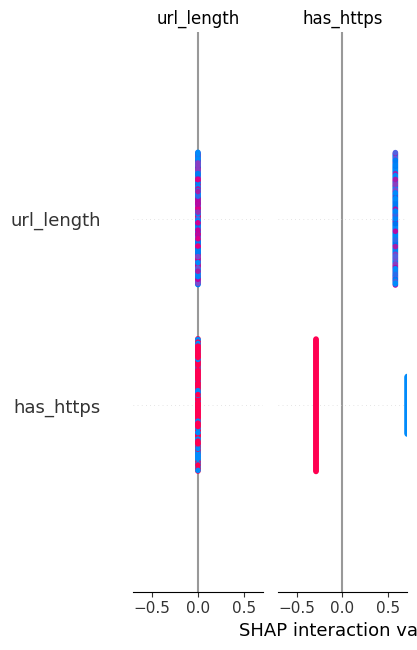

<Figure size 1000x600 with 0 Axes>

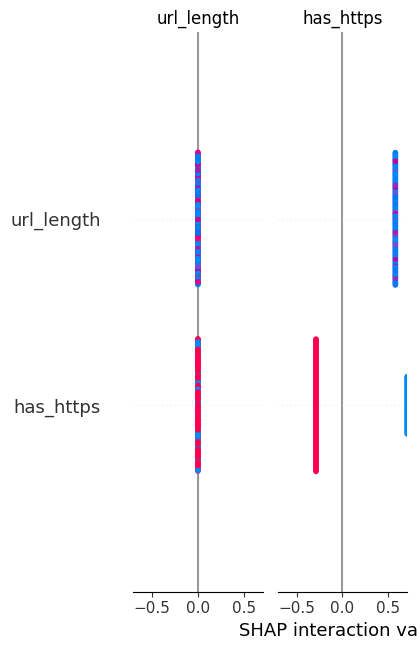


Top 5 Features Influencing URL Fraud Detection
             Feature    Importance
1          has_https  4.167259e-01
0         url_length  1.540434e-17
3      entropy_score  9.540979e-18
5    blacklist_match  9.332812e-18
4  domain_age_months  8.951173e-18

Top 3 Reasons for Prediction (Transaction Index 0)
      Feature  Value  SHAP Impact               Effect
0  url_length   23.0     0.289047  Increase Fraud Risk
1   has_https    1.0    -0.289047  Decrease Fraud Risk


In [11]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# ---------------- LOAD AND CLEAN DATA ----------------
data = pd.read_csv(r"D:\Projects\all_fraud_detection\notebook\url_fraud_dataset.csv")
data.columns = data.columns.str.strip().str.lower()

# Drop raw URL column
if 'url' in data.columns:
    data = data.drop(columns=['url'])

# Encode categorical
if 'source_channel' in data.columns:
    data['source_channel'] = LabelEncoder().fit_transform(data['source_channel'].astype(str))

# Features and target
X = data.drop('fraud_label', axis=1)
y = data['fraud_label']

print("Class Distribution:\n", y.value_counts())

# ---------------- TRAIN-TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------- PIPELINE ----------------
numeric_features = X.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)]
)

# Handle class imbalance for XGBoost
scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_weight,
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(model, r"D:\Projects\all_fraud_detection\models\url_model.pkl")
print("✅ URL Model Saved Successfully")

# ===============================
# SHAP Explainable AI for URL Dataset
# ===============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\nRunning SHAP Explainability...")

# Use the pipeline directly
# model = Pipeline(steps=[('preprocessor', ...), ('classifier', xgb_model)])

# Create SHAP Explainer
explainer = shap.Explainer(model.predict_proba, X_test)

# Get SHAP values
shap_values = explainer(X_test)

# ---------------- Global Feature Importance ----------------
# Summary plot (dot)
plt.figure(figsize=(10,6))  # increase figure size for full display
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# Bar plot (feature importance)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Top 5 global features
importance = np.abs(shap_values.values[:,:,1]).mean(axis=0)
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)
print("\nTop 5 Features Influencing URL Fraud Detection")
print(feature_importance.head(5))

# ---------------- Local Explanation ----------------
sample_index = 0
sample_shap = shap_values[sample_index].values[1]  # class 1 (fraud)
transaction = X_test.iloc[sample_index]

top_indices = np.argsort(np.abs(sample_shap))[::-1][:3]

reasons = []
for idx in top_indices:
    feature = X_test.columns[idx]
    value = transaction[feature]
    impact = sample_shap[idx]
    reasons.append({
        "Feature": feature,
        "Value": value,
        "SHAP Impact": float(impact),
        "Effect": "Increase Fraud Risk" if impact > 0 else "Decrease Fraud Risk"
    })

reasons_df = pd.DataFrame(reasons)
print("\nTop 3 Reasons for Prediction (Transaction Index 0)")
print(reasons_df)